In [67]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os
from scipy.optimize import curve_fit

Import my colony counts recorded in Excel

In [ ]:
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Results 16 October.xlsx"
data = pd.read_excel(path)

#Set dose levels and used plating numbers
Dose_levels = [0, 2, 5, 8]
Plating_numbers = [500, 1000, 3000, 6000]

#print(data)

In [203]:
def Perform_LQ_fit(doses, survival):
    #Generate LQ fit

    #inputs:
    #doses = list of used dose levels
    #survival = dictionary with survival data per dose level

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations
    
    def LQ_function(d, a, b):
        exponent = -(a*d + b*(np.square(d)))
        return exponent

    xvals = np.array(doses)
    yvals = np.array(list(survival.values()))
    yvals = np.log(yvals)

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(LQ_function, xvals, yvals, p0=p0, bounds=(0,1))
    
    return popt, LQ_function

In [ ]:
def Parse_data(doselevels, platingnumbers, input):
    #Split colony counting data into cell survival per dose level

    #inputs:
    #doselevels = list of the used dose levels
    #platingnumbers = list of the plating numbers for each dose level
    #input = dataframe with the dose and count for each sample

    output_survival = {}
    output_std = {}
    
    for i in range(len(doselevels)):
        dose = doselevels[i]
        plating_number = platingnumbers[i]

        #Isolate data from this dose level
        dose_level_data = input[input['Dose'] == dose]

        #Find average colony count
        average_count = dose_level_data['Count'].mean()

        #Calculate survival
        if i == 0:
            #If we're on the control sample, store value
            control_survival = average_count/plating_number
        survival = (average_count/plating_number)/control_survival

        #Write survival to dictionary
        output_survival[f"{dose} Gy"] = survival
        output_std[f"{dose} Gy"] = (dose_level_data['Count'].std()/plating_number)/control_survival

    return output_survival, output_std


Plot data and generate LQ curve for X-rays

{'0 Gy': 1.0, '2 Gy': 0.7916666666666666, '5 Gy': 0.14583333333333334, '8 Gy': 0.004629629629629629}
{'0 Gy': 0.6468406123441677, '2 Gy': 0.6005639710583156, '5 Gy': 0.1434998494428599, '8 Gy': 0.0020046884346862004}
[ 0.         -0.23361485 -1.92529086 -5.37527841]


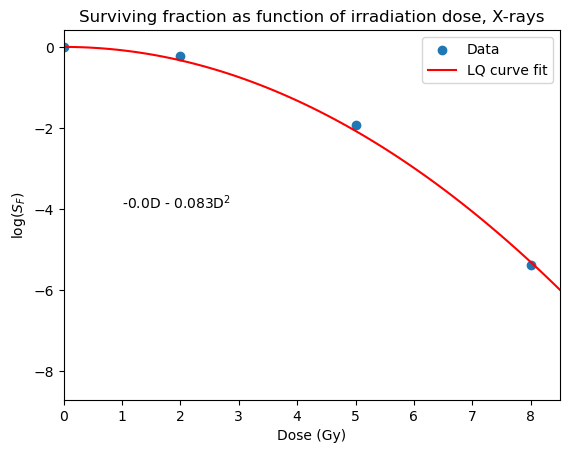

In [223]:
#Filter out X-ray results
X_ray_samples = data[data['Rad'] == 'X']

#Split per dose level
X_ray_survival, X_ray_survival_std = Parse_data(Dose_levels, Plating_numbers, X_ray_samples)

print(X_ray_survival)
print(X_ray_survival_std)

data_log = np.log(np.array(list(X_ray_survival.values())))
print(data_log)

params, LQ_func = Perform_LQ_fit(Dose_levels, X_ray_survival)

#Generate LQ fit plot
params, LQ_func = Perform_LQ_fit(Dose_levels, X_ray_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, data_log, label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params[0], params[1]), label='LQ curve fit', color = 'r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, X-rays')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params[0],3)}D - {round(params[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()
    

Plot data and generate LQ curve for protons low LET

{'0 Gy': 1.0, '2 Gy': 0.39189189189189183, '5 Gy': 0.08502252252252251, '8 Gy': 0.003378378378378378}
{'0 Gy': 0.16163342856629304, '2 Gy': 0.17476374535645356, '5 Gy': 0.03463181151955356, '8 Gy': 0.001462880749635876}


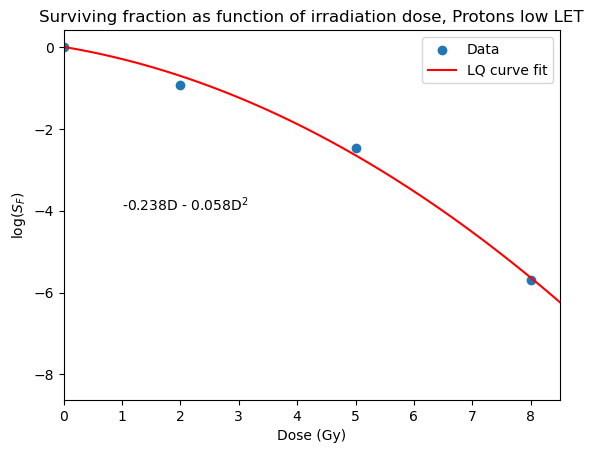

In [218]:
#Filter out proton low LET results
Proton_low_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton H')]

#Split per dose level
Proton_low_survival, Proton_low_survival_std = Parse_data(Dose_levels, Plating_numbers, Proton_low_samples)

print(Proton_low_survival)
print(Proton_low_survival_std)

#Generate LQ fit plot
params, LQ_func = Perform_LQ_fit(Dose_levels, Proton_low_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params[0], params[1]), label='LQ curve fit', color='r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons low LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params[0],3)}D - {round(params[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot data and generate LQ curve for protons high LET

{'0 Gy': 1.0, '2 Gy': 0.20270270270270271, '5 Gy': 0.04842342342342343, '8 Gy': 0.015484234234234232}
{'0 Gy': 0.16163342856629304, '2 Gy': 0.11183146870294211, '5 Gy': 0.0795235634201016, '8 Gy': 0.02390864160536278}
[ 0.         -1.59601489 -3.02777163 -4.16793292]


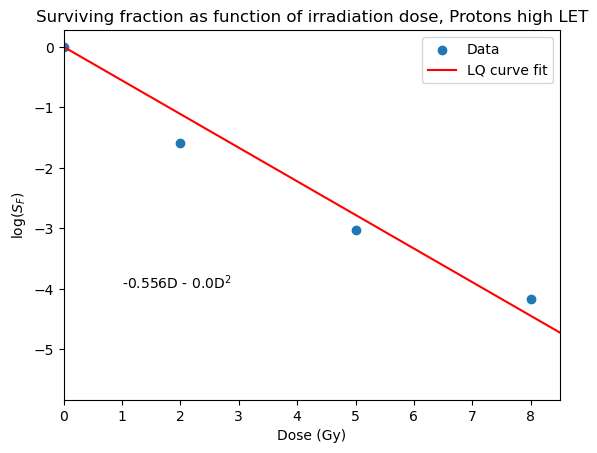

In [221]:
#Filter out proton high LET results
Proton_high_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton L')]

#Split per dose level
Proton_high_survival, Proton_high_survival_std = Parse_data(Dose_levels, Plating_numbers, Proton_high_samples)

print(Proton_high_survival)
print(Proton_high_survival_std)

data_log = np.log(np.array(list(Proton_high_survival.values())))
print(data_log)

params, LQ_func = Perform_LQ_fit(Dose_levels, Proton_high_survival)

#Generate LQ fit plot
params, LQ_func = Perform_LQ_fit(Dose_levels, Proton_high_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, data_log, label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params[0], params[1]), label='LQ curve fit', color='r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons high LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params[0],3)}D - {round(params[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot all data together

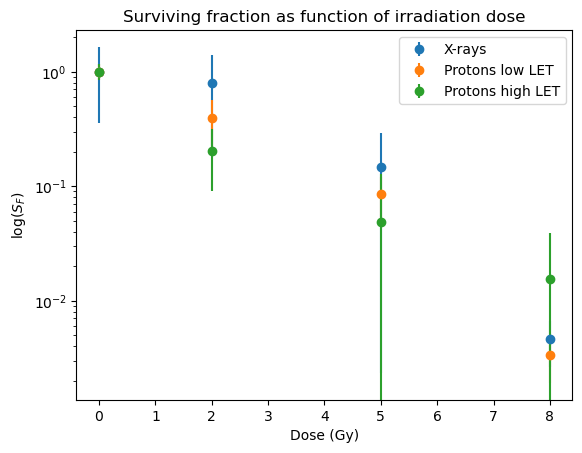

In [66]:
plt.errorbar(Dose_levels, list(X_ray_survival.values()), yerr=list(X_ray_survival_std.values()), fmt='o', label='X-rays')
plt.errorbar(Dose_levels, list(Proton_low_survival.values()), yerr=list(Proton_low_survival_std.values()), fmt='o', label='Protons low LET')
plt.errorbar(Dose_levels, list(Proton_high_survival.values()), yerr=list(Proton_high_survival_std.values()), fmt='o', label='Protons high LET')
plt.yscale('log')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose')
plt.legend()